In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/students-performance-in-exams/StudentsPerformance.csv


In [28]:
# Student Performance Analysis - Data Science Mini Project

#This project explores the relationship between student demographics, parental background, test preparation, and performance in math, reading, and writing using the Kaggle "Students Performance" dataset.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("/kaggle/input/students-performance-in-exams/StudentsPerformance.csv")


In [31]:
#Displaying the dataset
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [32]:
#Q1. What is the average math score of students by gender?

In [33]:
df.groupby('gender')['math score'].mean() #as there exist mean instead of average

gender
female    63.633205
male      68.728216
Name: math score, dtype: float64

In [34]:
#Q2. What is the average writing score for each race/ethnicity group?

In [35]:
df.groupby('race/ethnicity')['writing score'].mean()

race/ethnicity
group A    62.674157
group B    65.600000
group C    67.827586
group D    70.145038
group E    71.407143
Name: writing score, dtype: float64

In [36]:
#Q3. What is the average reading score of students who completed the test preparation course
#vs those who didn’t?

In [37]:
df.groupby('test preparation course')['reading score'].mean()
#as test prep contains completed and none section so it will be divided accordingly

test preparation course
completed    73.893855
none         66.534268
Name: reading score, dtype: float64

In [38]:
#Q4. Who scored the highest total across all subjects?

In [39]:
df['total']=df['math score']+ df['reading score'] + df['writing score']
df.loc[df['total'].idxmax()]
#this will give location of the max index from the total column(whole row)

gender                                    female
race/ethnicity                           group E
parental level of education    bachelor's degree
lunch                                   standard
test preparation course                     none
math score                                   100
reading score                                100
writing score                                100
total                                        300
Name: 458, dtype: object

In [40]:
topper= df.loc[df['total'].idxmax()]
print(topper['gender'], topper['total'])

female 300


In [41]:
#Q5. What percentage of students scored above 90 in all three subjects?

In [42]:
high_achievers = df[
    (df['math score'] > 90) &
    (df['reading score'] > 90) &
    (df['writing score'] > 90)
] #count of all the high scores

percentage = (len(high_achievers) / len(df)) * 100 #percentage formula
print(f"{percentage:.2f}% of students scored above 90 in all subjects.") #for float


2.30% of students scored above 90 in all subjects.


In [43]:
#Q6 What is the impact of lunch type (standard vs free/reduced) on scores in each subject?

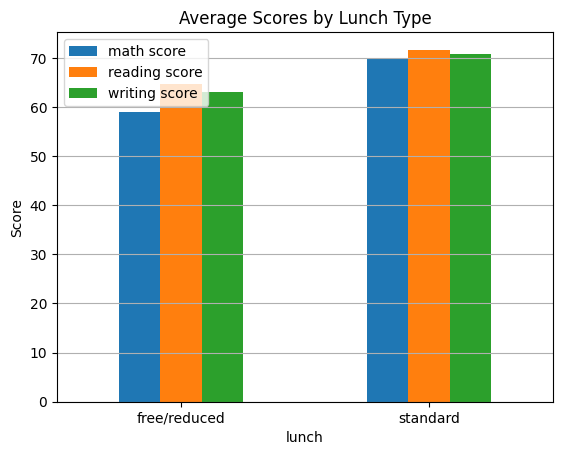

In [44]:
df.groupby('lunch')[['math score', 'reading score', 'writing score']].mean().plot(kind='bar')
plt.title('Average Scores by Lunch Type') #title of the bar graph
plt.ylabel('Score') #defining Y axis
plt.xticks(rotation=0) #text beneath will be horizontal
plt.grid(axis='y') #grid lines through Y-axis
plt.show()


In [45]:
#Q7.What is the impact of parental level of education on average scores?

In [46]:
df['total'] = df['math score'] + df['reading score'] + df['writing score']

df.groupby('parental level of education')['total'].mean()

parental level of education
associate's degree    208.707207
bachelor's degree     215.771186
high school           189.290816
master's degree       220.796610
some college          205.429204
some high school      195.324022
Name: total, dtype: float64

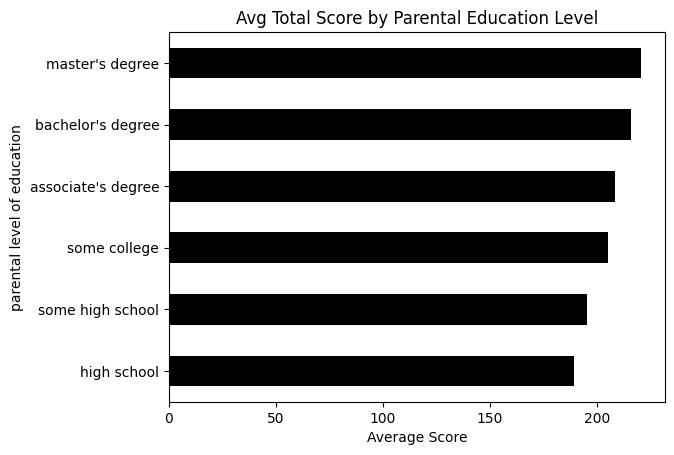

In [47]:
df.groupby('parental level of education')['total'].mean().sort_values().plot(kind='barh', color='black')
plt.title('Avg Total Score by Parental Education Level')
plt.xlabel('Average Score') #for x axis labelling
plt.show()
#barh is bar in horizontal, default bar is vertical

In [48]:
#Q8.Which race/ethnicity group has the highest average overall score?

In [50]:
df.groupby('race/ethnicity')['total'].mean().sort_values(ascending=False)

race/ethnicity
group E    218.257143
group D    207.538168
group C    201.394984
group B    196.405263
group A    188.977528
Name: total, dtype: float64

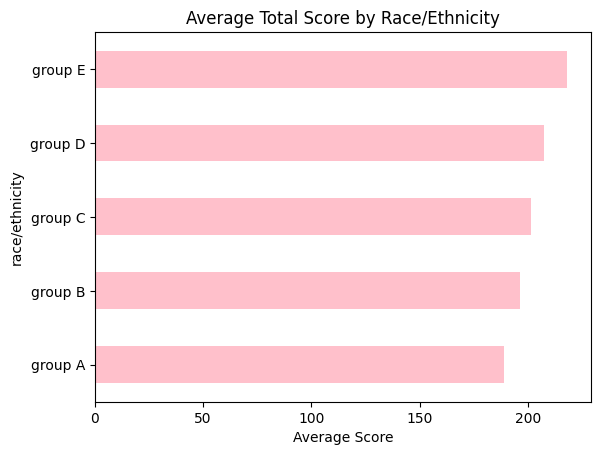

In [56]:
df.groupby('race/ethnicity')['total'].mean().sort_values().plot(kind='barh', color='pink')
plt.title('Average Total Score by Race/Ethnicity')
plt.xlabel('Average Score')
plt.show()

In [60]:
#Q9 Do students from different race/ethnicity groups benefit equally from test preparation?


In [61]:
df.groupby(['race/ethnicity', 'test preparation course'])['total'].mean()


race/ethnicity  test preparation course
group A         completed                  210.193548
                none                       177.637931
group B         completed                  211.926471
                none                       187.754098
group C         completed                  215.606838
                none                       193.163366
group D         completed                  220.597561
                none                       201.588889
group E         completed                  230.083333
                none                       209.387500
Name: total, dtype: float64

In [62]:
#Q10. Create a new column for average percentage and classify students as Pass/Fail (use 40% as pass mark).



In [63]:
# Create average percentage column
df['percentage'] = df['total'] / 300 * 100

# Create Pass/Fail column
df['result'] = df['percentage'].apply(lambda x: 'Pass' if x >= 40 else 'Fail')

# Optional: Preview first 5 rows
df[['math score', 'reading score', 'writing score', 'total', 'percentage', 'result']].head()


,math score,reading score,writing score,total,percentage,result
0,72,72,74,218,72.666667,Pass
1,69,90,88,247,82.333333,Pass
2,90,95,93,278,92.666667,Pass
3,47,57,44,148,49.333333,Pass
4,76,78,75,229,76.333333,Pass


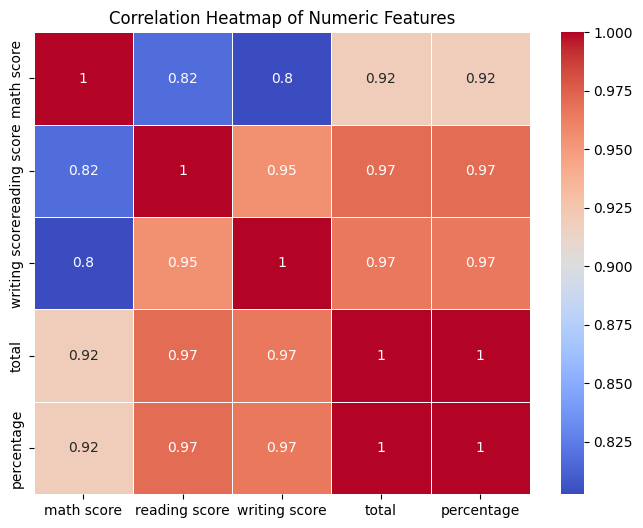

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Step 2: Plot heatmap on the numeric data
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [68]:
## 🧠 Key Takeaways

#- Students who completed the test preparation course scored ~10% higher on average.
#- Parental education positively correlates with performance.
#- Gender gaps appear in writing and reading more than in math.
#- Correlation heatmap shows strong relationships between the three subject scores.




In [ ]:
##  Dataset Reference

#- Source: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
#- No missing values, well-structured CSV with 1000 entries
